In [1]:
import sys; sys.path.append('../src/sde_hjb_solver')

import matplotlib.pyplot as plt
import numpy as np

from hjb_solver_2d_st import SolverHJB2D
from controlled_sde_2d import TripleWellCommittor2D
from base_parser import get_base_parser

from config import DATA_ROOT_DIR

## Triple well committor setting

The committor setting with a triple well potential in 2d can be found in *[Metzner, 2007]* and *[Hartmann et. al, 2014]* for
* low metastability: $\beta=5/3=1.666$ ($\beta^{-1} = 0.6$)
* high metastability: $\beta=20/3=6.66$ ($\beta^{-1} = 0.15$)

In [2]:
# initialize controlled sde object
sde = TripleWellCommittor2D(beta=1.)

# initialize hjb solver object
sol_hjb = SolverHJB2D(sde, h=5e-2)

# directory
dir_path = DATA_ROOT_DIR + '/notebooks/'
experiment_name = 'triplewell_2d_committor'

In [3]:
# compute hjb solution 
sol_hjb.solve_bvp()
sol_hjb.compute_value_function()
sol_hjb.compute_optimal_control()
sol_hjb.save()

In [4]:
# report
sol_hjb.write_report(x=-1)


 space discretization
h = 0.0500
N_h = 3721

 psi, value function and optimal control at x


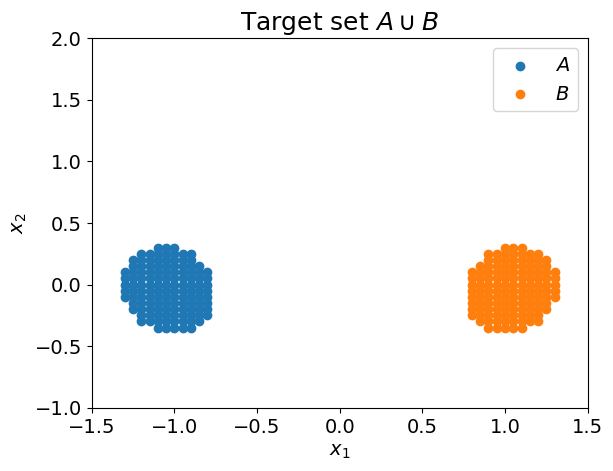

In [5]:
# plot target sets
fig, ax = sde.plot_target_set()

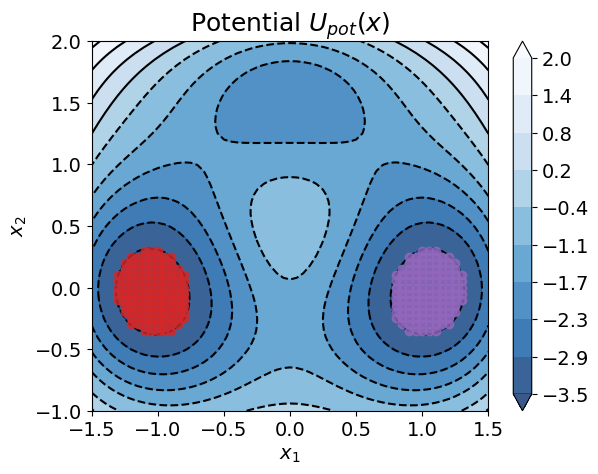

In [7]:
# plot potential
pot_levels = np.linspace(-3.5, 2, 10).round(decimals=1)
fig, ax = sde.plot_2d_potential(
    levels=pot_levels,
    #x_init=(0, 0.5),
)

# add target sets
x = sde.domain_h.reshape(sde.Nh, sde.d)
set_a = x[sde.ts_a_idx]
set_b = x[sde.ts_b_idx]
ax.scatter(set_a[:, 0], set_a[:, 1], c='tab:red', alpha=0.8, label=r'$A$', zorder=5)
ax.scatter(set_b[:, 0], set_b[:, 1], c='tab:purple', alpha=0.8, label=r'$B$', zorder=5)
fig.savefig(dir_path + 'triplewell_2d_potential.png', bbox_inches='tight')

In [11]:
# evaluate in grid
sol_hjb.get_perturbed_potential_and_drift()

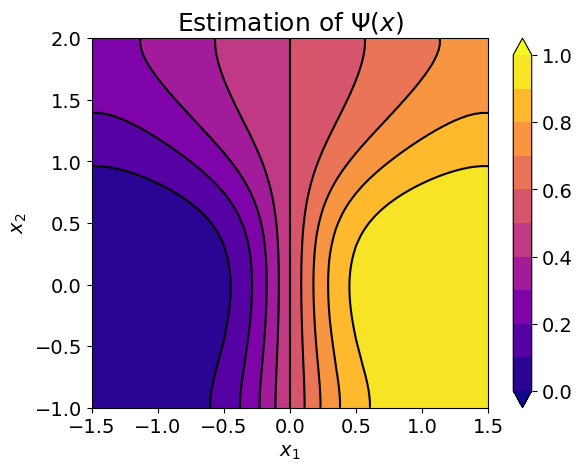

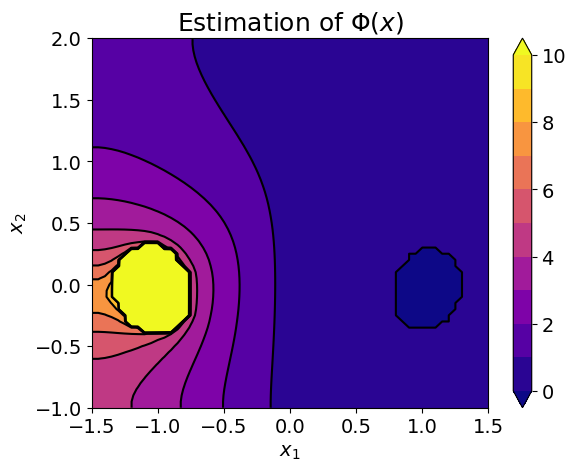

In [12]:
# plot quantity of interest psi
fig, ax = sol_hjb.plot_2d_psi(
    levels=np.linspace(0, 1, 11),
)
fig.savefig(dir_path + experiment_name + '_psi.png', bbox_inches='tight')

# plot value function
fig, ax = sol_hjb.plot_2d_value_function(
    levels=np.linspace(0, 10, 11),
)

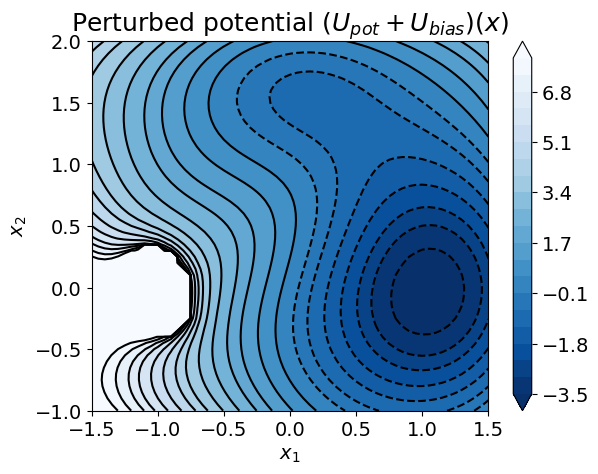

In [13]:
# plot perturbed potential
pot_levels = np.linspace(-3.5, 8, 21).round(decimals=1)
fig, ax = sol_hjb.plot_2d_perturbed_potential(levels=pot_levels)
fig.savefig(dir_path + experiment_name + '_perturbed-potential.png', bbox_inches='tight')

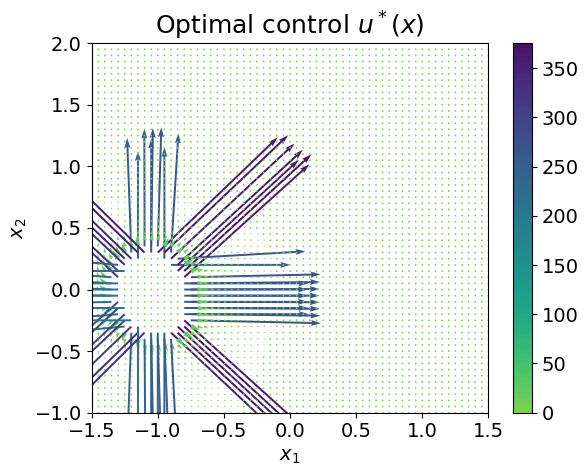

In [14]:
# plot_2d_control
fig, ax = sol_hjb.plot_2d_control(scale=None, width=0.005)
#fig.savefig(dir_path + experiment_name + '_control.png', bbox_inches='tight')